Lloyds Banking Group – Customer Churn Analysis

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [37]:
# Load all sheets from the Excel file
file_path = "./data/Customer_Churn_Data_Large (1).xlsx"

customer_demo = pd.read_excel(file_path, sheet_name='Customer_Demographics')
transaction_history = pd.read_excel(file_path, sheet_name='Transaction_History')
customer_service = pd.read_excel(file_path, sheet_name='Customer_Service')
online_activity = pd.read_excel(file_path, sheet_name='Online_Activity')
churn_status = pd.read_excel(file_path, sheet_name='Churn_Status')

In [38]:
customer_demo.head()


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [39]:
customer_demo.info()
customer_demo.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB


,CustomerID,Age
count,1000.000000,1000.000000
mean,500.500000,43.267000
std,288.819436,15.242311
min,1.000000,18.000000
25%,250.750000,30.000000
50%,500.500000,43.000000
75%,750.250000,56.000000
max,1000.000000,69.000000


Transaction History

In [40]:
transaction_history.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [41]:
transaction_history.info()
transaction_history.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[ns]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 197.6+ KB


,CustomerID,TransactionID,TransactionDate,AmountSpent
count,5054.000000,5054.000000,5054,5054.000000
mean,501.424218,5510.538979,2022-07-01 19:25:37.158686208,250.707351
min,1.000000,1000.000000,2022-01-01 00:00:00,5.180000
25%,251.000000,3242.000000,2022-04-03 00:00:00,127.105000
50%,506.000000,5530.000000,2022-07-01 00:00:00,250.525000
75%,749.000000,7680.750000,2022-09-29 00:00:00,373.412500
max,1000.000000,9997.000000,2022-12-31 00:00:00,499.860000
std,285.172780,2582.088012,NaN,142.250838


Customer Service Dataset

In [42]:
customer_service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [43]:
customer_service.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1002 non-null   int64         
 1   InteractionID     1002 non-null   int64         
 2   InteractionDate   1002 non-null   datetime64[ns]
 3   InteractionType   1002 non-null   object        
 4   ResolutionStatus  1002 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 39.3+ KB


Online Activity Dataset

In [44]:
online_activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [45]:
online_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      1000 non-null   int64         
 1   LastLoginDate   1000 non-null   datetime64[ns]
 2   LoginFrequency  1000 non-null   int64         
 3   ServiceUsage    1000 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 31.4+ KB


Churn Status Dataset

In [46]:
churn_status.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [47]:
churn_status['ChurnStatus'].value_counts()

ChurnStatus
0    796
1    204
Name: count, dtype: int64

Data Merging

Aggregate Transaction Data

In [48]:
transaction_agg = transaction_history.groupby('CustomerID').agg({
    'AmountSpent': ['sum', 'mean', 'count']
}).reset_index()

transaction_agg.columns = ['CustomerID', 'TotalSpent', 'AverageSpent', 'TransactionCount']

transaction_agg.head()

,CustomerID,TotalSpent,AverageSpent,TransactionCount
0,1,416.50,416.50000,1
1,2,1547.42,221.06000,7
2,3,1702.98,283.83000,6
3,4,917.29,183.45800,5
4,5,2001.49,250.18625,8


Aggregate Customer Service Data

In [49]:
service_agg = customer_service.groupby('CustomerID').agg({
    'InteractionID': 'count'
}).reset_index()

service_agg.columns = ['CustomerID', 'ServiceInteractionCount']

service_agg.head()

,CustomerID,ServiceInteractionCount
0,1,1
1,2,1
2,3,1
3,4,2
4,6,1


Merge All Datasets

In [50]:
merged_data = customer_demo.merge(transaction_agg, on='CustomerID', how='left')
merged_data = merged_data.merge(service_agg, on='CustomerID', how='left')
merged_data = merged_data.merge(online_activity, on='CustomerID', how='left')
merged_data = merged_data.merge(churn_status, on='CustomerID', how='left')

merged_data.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TotalSpent,AverageSpent,TransactionCount,ServiceInteractionCount,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,416.50,416.50000,1,1.0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,1547.42,221.06000,7,1.0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,1702.98,283.83000,6,1.0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,917.29,183.45800,5,2.0,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,2001.49,250.18625,8,NaN,2023-10-27,41,Website,0


In [51]:
merged_data.shape

(1000, 13)

Exploratory Data Analysis (EDA)

In [52]:
merged_data.isnull().sum()

CustomerID                   0
Age                          0
Gender                       0
MaritalStatus                0
IncomeLevel                  0
TotalSpent                   0
AverageSpent                 0
TransactionCount             0
ServiceInteractionCount    332
LastLoginDate                0
LoginFrequency               0
ServiceUsage                 0
ChurnStatus                  0
dtype: int64

In [53]:
# Fill missing service interaction counts with 0
merged_data['ServiceInteractionCount'] = merged_data['ServiceInteractionCount']

Descriptive Statistics

In [54]:
merged_data.describe()

,CustomerID,Age,TotalSpent,AverageSpent,TransactionCount,ServiceInteractionCount,LastLoginDate,LoginFrequency,ChurnStatus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,668.000000,1000,1000.000000,1000.000000
mean,500.500000,43.267000,1267.074950,248.806511,5.054000,1.500000,2023-07-05 21:28:48,25.912000,0.204000
min,1.000000,18.000000,9.800000,9.800000,1.000000,1.000000,2023-01-01 00:00:00,1.000000,0.000000
25%,250.750000,30.000000,626.685000,203.734167,3.000000,1.000000,2023-04-08 00:00:00,13.750000,0.000000
50%,500.500000,43.000000,1232.880000,250.121458,5.000000,1.500000,2023-07-10 12:00:00,27.000000,0.000000
75%,750.250000,56.000000,1791.902500,295.023854,7.000000,2.000000,2023-10-01 06:00:00,38.000000,0.000000
max,1000.000000,69.000000,3386.040000,496.990000,9.000000,2.000000,2023-12-31 00:00:00,49.000000,1.000000
std,288.819436,15.242311,738.590013,79.372766,2.603433,0.500375,NaN,14.055953,0.403171


Churn Distribution

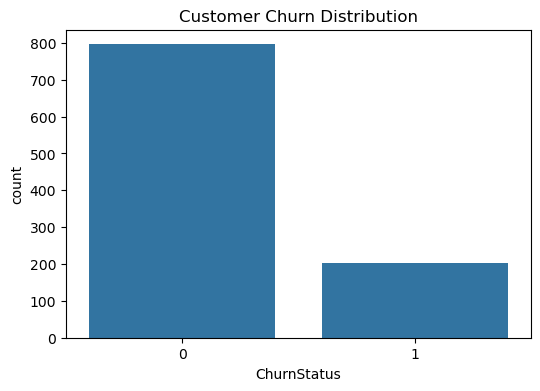

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x='ChurnStatus', data=merged_data)
plt.title('Customer Churn Distribution')
plt.show()

Age Distribution

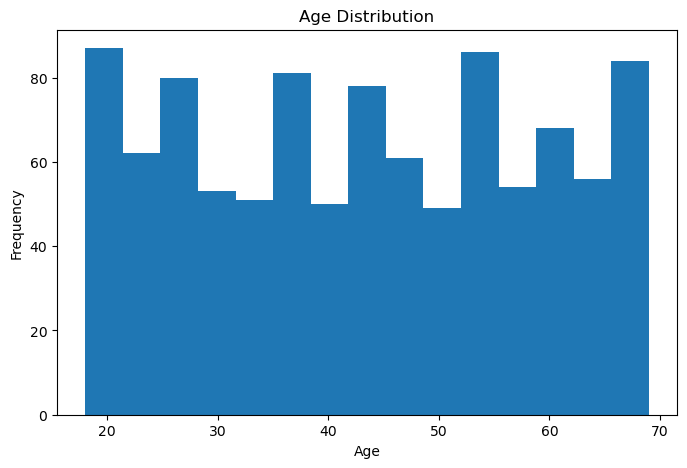

In [56]:
plt.figure(figsize=(8,5))
plt.hist(merged_data['Age'], bins=15)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Total Spending Distribution

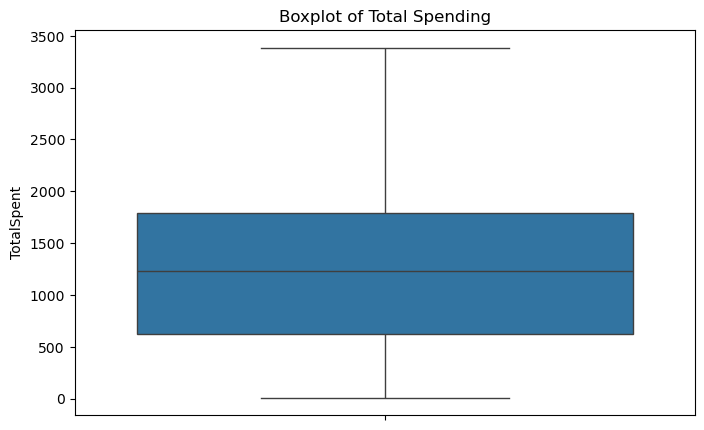

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(y=merged_data['TotalSpent'])
plt.title('Boxplot of Total Spending')
plt.show()

Login Frequency vs Churn

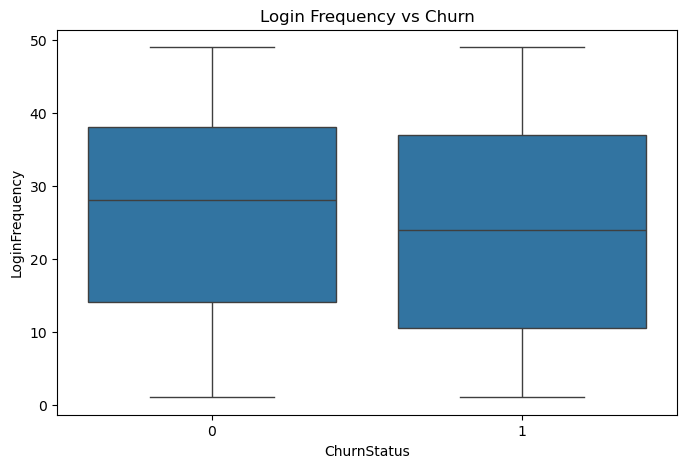

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=merged_data)
plt.title('Login Frequency vs Churn')
plt.show()

Correlation Analysis

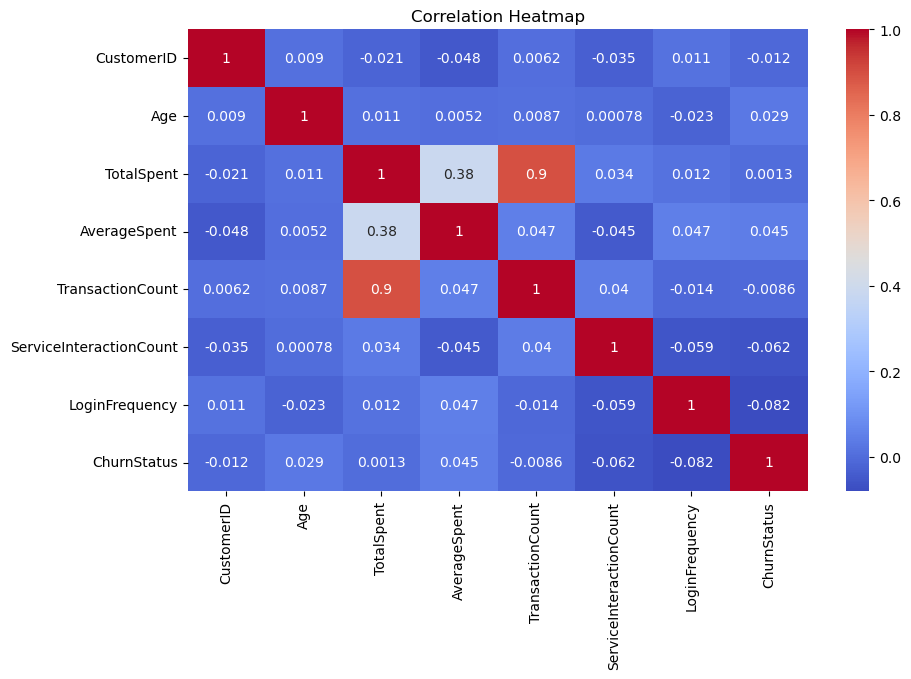

In [59]:
numeric_data = merged_data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Outlier Detection

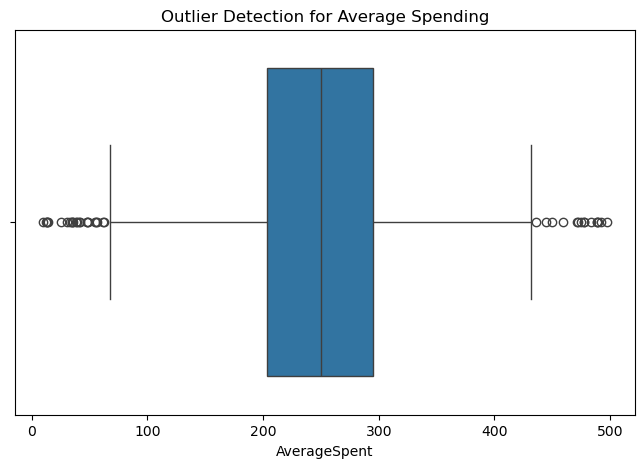

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x=merged_data['AverageSpent'])
plt.title('Outlier Detection for Average Spending')
plt.show()

Data Preprocessing

In [61]:
categorical_columns = ['Gender', 'MaritalStatus', 'IncomeLevel']

merged_data_encoded = pd.get_dummies(merged_data, columns=categorical_columns, drop_first=True)

merged_data_encoded.head()

,CustomerID,Age,TotalSpent,AverageSpent,TransactionCount,ServiceInteractionCount,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium
0,1,62,416.50,416.50000,1,1.0,2023-10-21,34,Mobile App,0,True,False,True,False,True,False
1,2,65,1547.42,221.06000,7,1.0,2023-12-05,5,Website,1,True,True,False,False,True,False
2,3,18,1702.98,283.83000,6,1.0,2023-11-15,3,Website,0,True,False,True,False,True,False
3,4,21,917.29,183.45800,5,2.0,2023-08-25,2,Website,0,True,False,False,True,True,False
4,5,21,2001.49,250.18625,8,NaN,2023-10-27,41,Website,0,True,False,False,False,False,True


Feature Scaling

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = ['Age', 'TotalSpent', 'AverageSpent', 'TransactionCount',
                     'ServiceInteractionCount', 'LoginFrequency']

merged_data_encoded[numerical_columns] = scaler.fit_transform(
    merged_data_encoded[numerical_columns]
)

merged_data_encoded.head()

,CustomerID,Age,TotalSpent,AverageSpent,TransactionCount,ServiceInteractionCount,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium
0,1,1.229628,-1.152196,2.113790,-1.557954,-1.0,2023-10-21,0.575702,Mobile App,0,True,False,True,False,True,False
1,2,1.426547,0.379758,-0.349747,0.747849,-1.0,2023-12-05,-1.488513,Website,1,True,True,False,False,True,False
2,3,-1.658518,0.590481,0.441474,0.363548,-1.0,2023-11-15,-1.630872,Website,0,True,False,True,False,True,False
3,4,-1.461599,-0.473822,-0.823723,-0.020752,1.0,2023-08-25,-1.702052,Website,0,True,False,False,True,True,False
4,5,-1.461599,0.994845,0.017392,1.132149,NaN,2023-10-27,1.073961,Website,0,True,False,False,False,False,True


Final Cleaned Dataset

In [63]:
merged_data_encoded.shape
merged_data_encoded.head()

,CustomerID,Age,TotalSpent,AverageSpent,TransactionCount,ServiceInteractionCount,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium
0,1,1.229628,-1.152196,2.113790,-1.557954,-1.0,2023-10-21,0.575702,Mobile App,0,True,False,True,False,True,False
1,2,1.426547,0.379758,-0.349747,0.747849,-1.0,2023-12-05,-1.488513,Website,1,True,True,False,False,True,False
2,3,-1.658518,0.590481,0.441474,0.363548,-1.0,2023-11-15,-1.630872,Website,0,True,False,True,False,True,False
3,4,-1.461599,-0.473822,-0.823723,-0.020752,1.0,2023-08-25,-1.702052,Website,0,True,False,False,True,True,False
4,5,-1.461599,0.994845,0.017392,1.132149,NaN,2023-10-27,1.073961,Website,0,True,False,False,False,False,True


Export Cleaned Dataset

In [64]:
merged_data_encoded.to_csv('Cleaned_Customer_Churn_Data.csv', index=False)